In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [193]:
data = pd.read_csv("11-iris.csv")

In [194]:
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [195]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [196]:
data["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [197]:
data.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


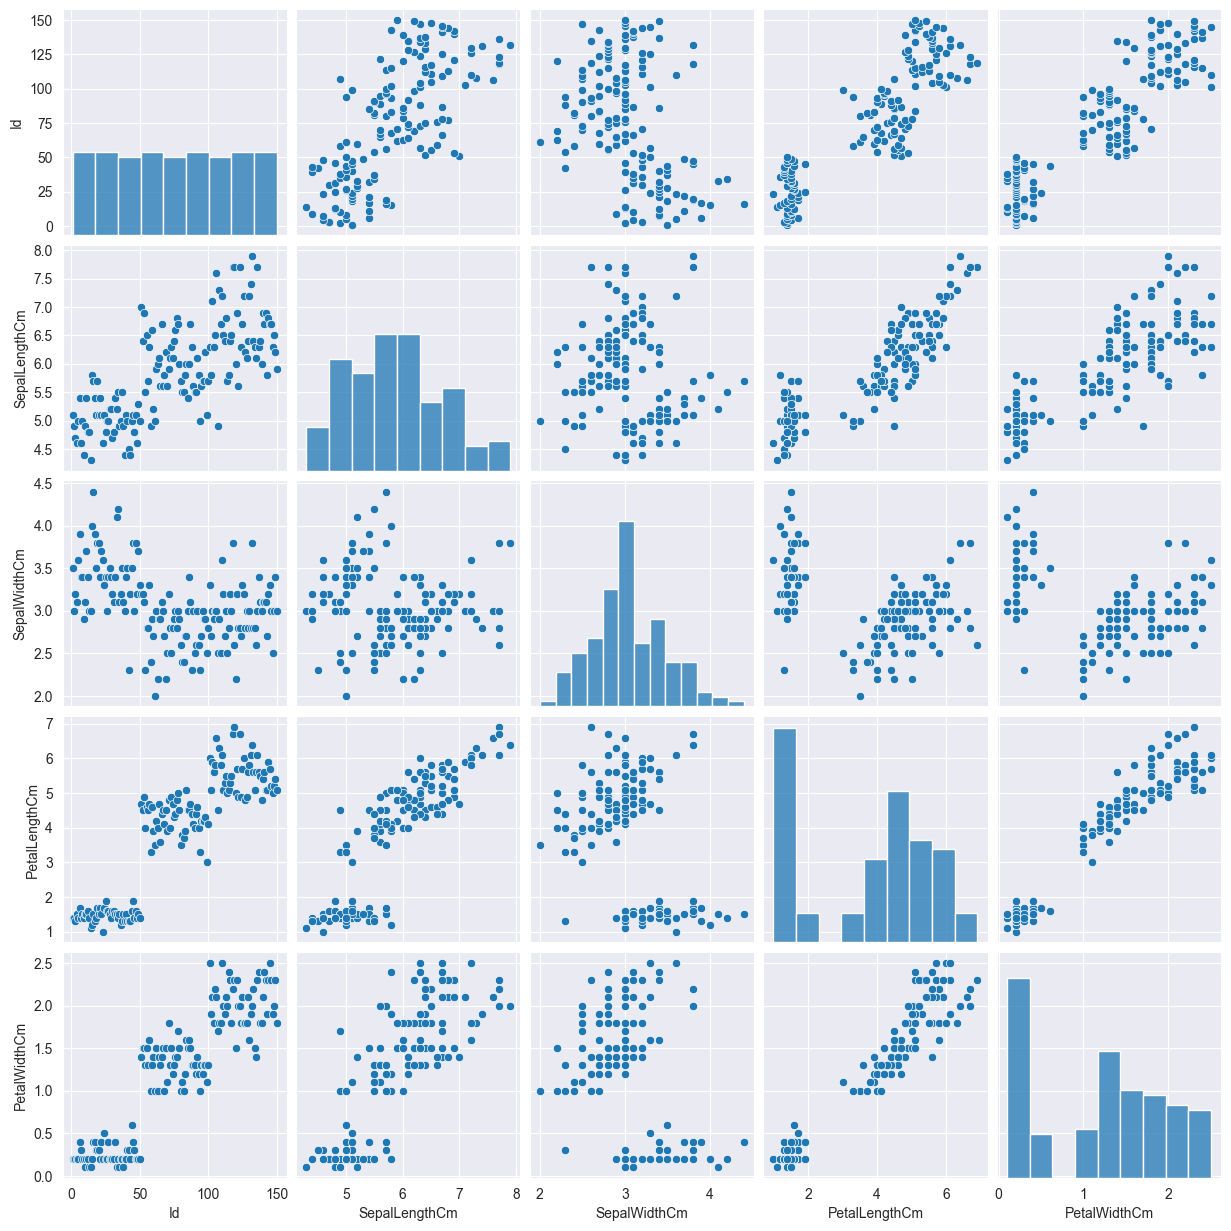

In [198]:
sns.pairplot(data)
plt.show()

In [199]:
data.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

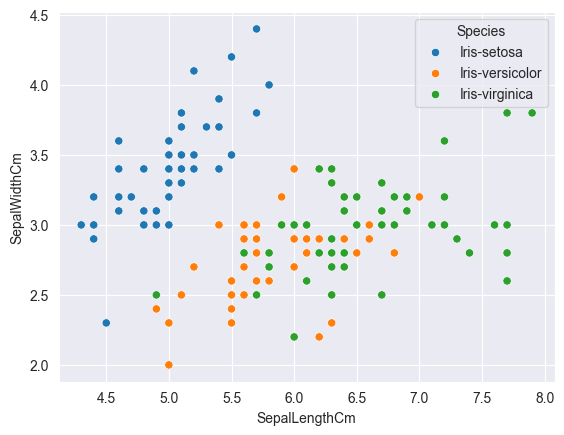

In [200]:
sns.scatterplot(x= data["SepalLengthCm"], y= data["SepalWidthCm"], hue= data["Species"])
plt.show()

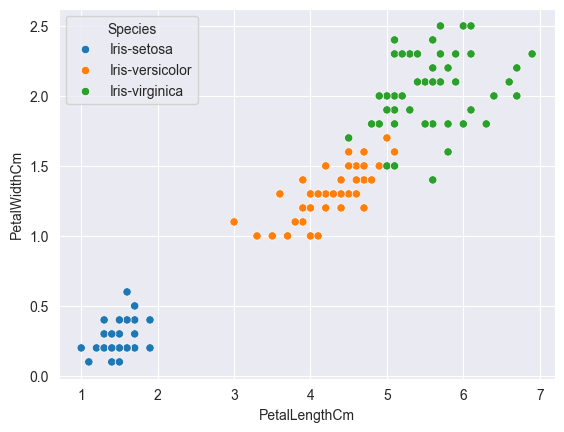

In [201]:
sns.scatterplot(x= data["PetalLengthCm"], y= data["PetalWidthCm"], hue= data["Species"])
plt.show()

array([[<Axes: title={'center': 'PetalLengthCm'}, xlabel='[Species]'>,
        <Axes: title={'center': 'PetalWidthCm'}, xlabel='[Species]'>],
       [<Axes: title={'center': 'SepalLengthCm'}, xlabel='[Species]'>,
        <Axes: title={'center': 'SepalWidthCm'}, xlabel='[Species]'>]],
      dtype=object)

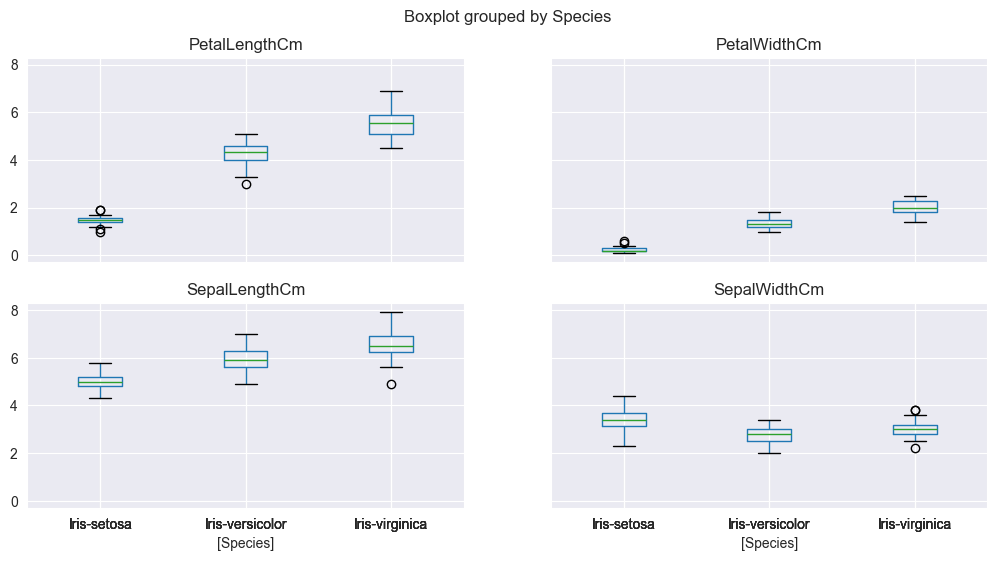

In [202]:
data.drop("Id", axis=1).boxplot(by="Species", figsize=(12, 6))

In [203]:
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [204]:
data = data.drop("Id", axis = 1)

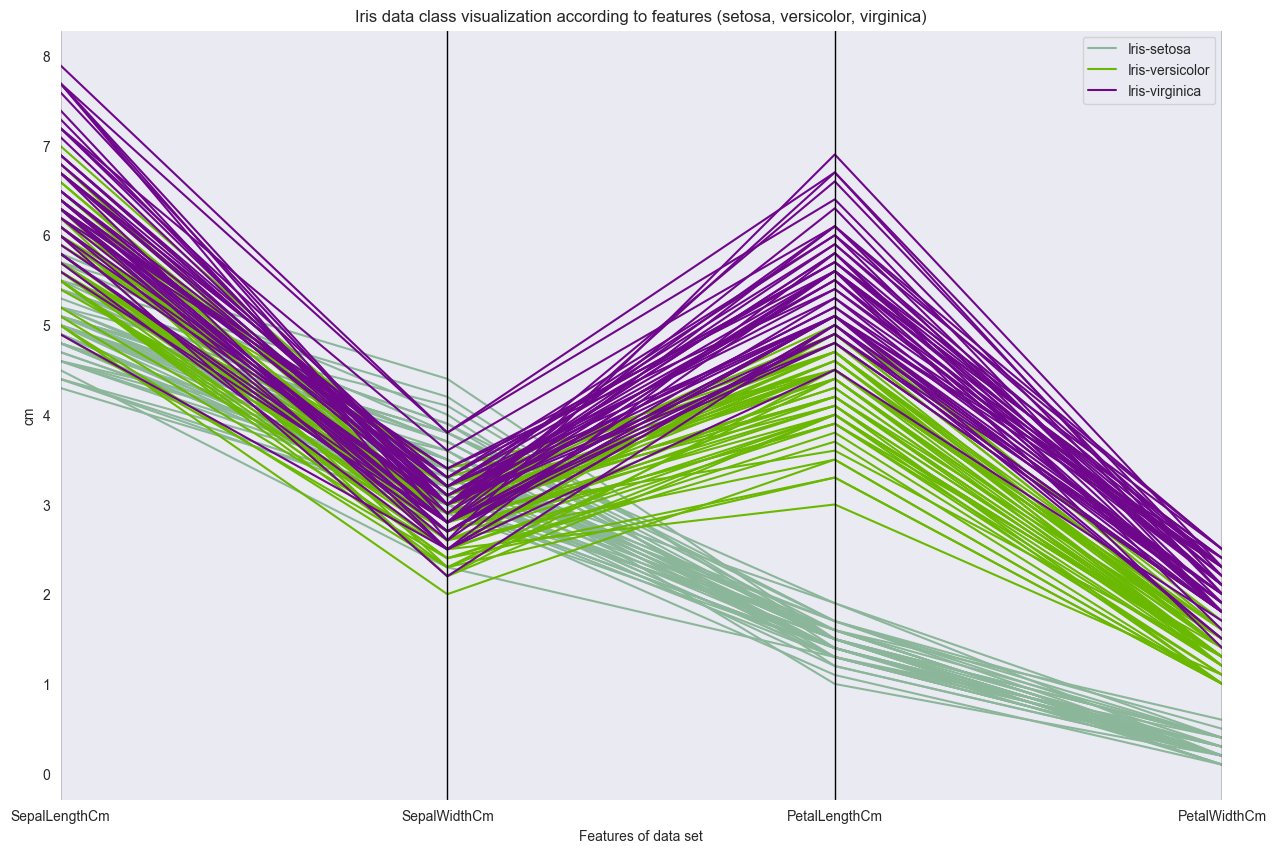

In [206]:
from pandas.plotting import parallel_coordinates

plt.figure(figsize=(15,10))
parallel_coordinates(data, "Species")
plt.title("Iris data class visualization according to features (setosa, versicolor, virginica)")
plt.xlabel("Features of data set")
plt.ylabel("cm")
plt.show()

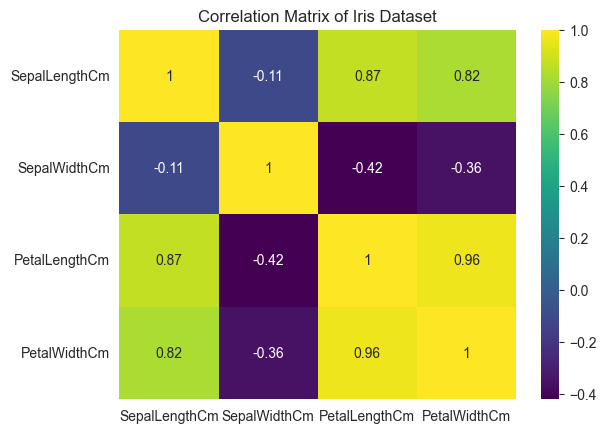

In [207]:
corr = data.drop("Species", axis=1).corr()
sns.heatmap(corr, annot=True, cmap='viridis')
plt.title("Correlation Matrix of Iris Dataset")
plt.show()

In [208]:
from sklearn.preprocessing import LabelEncoder

In [209]:
label_encoder = LabelEncoder()
data["Species"] = label_encoder.fit_transform(data["Species"])

In [210]:
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [211]:
data.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [212]:
data["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [213]:
X = data.drop("Species", axis = 1)
y = data["Species"]

In [214]:
from sklearn.model_selection import train_test_split

In [215]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [216]:
from sklearn.preprocessing import StandardScaler

In [217]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [218]:
from sklearn.naive_bayes import GaussianNB

In [219]:
# https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html
# There is no need for hyperparameter tuning in GausianNB because it does not have different parameters.
gnb = GaussianNB()

In [220]:
gnb.fit(X_train_scaled, y_train)
y_pred = gnb.predict(X_test_scaled)

In [221]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [222]:
print("Confusion Matrix: \n", confusion_matrix(y_pred, y_test))
print("Classification Report: \n", classification_report(y_pred, y_test))
print("Accuracy Score:", accuracy_score(y_pred, y_test))

Confusion Matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

Accuracy Score: 1.0


In [223]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [224]:
penalty = ["l1","l2","elasticnet"]
c_values = [100, 10, 1.0, 0.1, 0.01]
solver = ["newton_cg", "lbfgs", "liblinear", "sag", "saga", "newton-cholesky"]

In [225]:
params = dict(penalty = penalty, C = c_values, solver = solver)

In [226]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [227]:
cv = StratifiedKFold()

In [228]:
grid = GridSearchCV(estimator=model, param_grid=params, scoring="accuracy", cv=cv)

In [229]:
import warnings
warnings.filterwarnings("ignore")

grid.fit(X_train_scaled, y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton_cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [230]:
y_pred = grid.predict(X_test_scaled)

In [231]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [232]:
print("Confusion Matrix: \n", confusion_matrix(y_pred, y_test))
print("Classification Report: \n", classification_report(y_pred, y_test))
print("Accuracy Score:", accuracy_score(y_pred, y_test))

Confusion Matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

Accuracy Score: 1.0


In [233]:
grid.best_params_

{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

In [234]:
#SVC

In [235]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Mean Absolute Error: 0.13709222254309364
Mean Squared Error: 0.02981036088013027
R-Squared: 0.9436282380839741


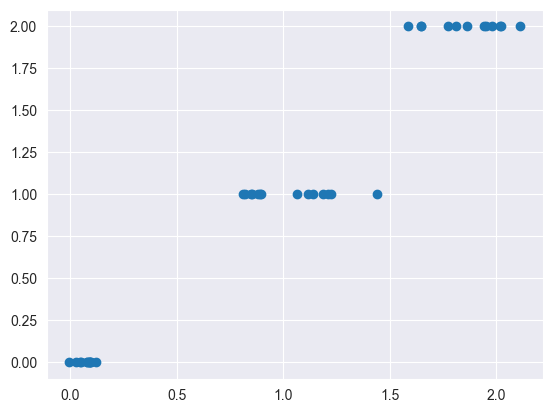

In [236]:
svr = SVR()
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

mae = mean_absolute_error(y_pred, y_test)
mse = mean_squared_error(y_pred, y_test)
r2 = r2_score(y_pred, y_test)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-Squared:", r2)

plt.scatter(y_pred, y_test)
plt.show()

In [237]:
from sklearn.model_selection import GridSearchCV

In [238]:
param_grid = {
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
    "gamma" : [1, 0.1,0.01, 0.001],
    "C" : [0.1, 1, 10, 100, 1000]
}

In [239]:
grid_svm = GridSearchCV(estimator=SVR(), param_grid=param_grid, n_jobs=-1, verbose=3)

In [240]:
grid_svm.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,estimator,SVR()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['linear', 'poly', ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


In [241]:
grid_svm.best_params_

{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

Mean Absolute Error: 0.13195961522708213
Mean Squared Error: 0.031645110207524606
R-Squared: 0.9473288642154003


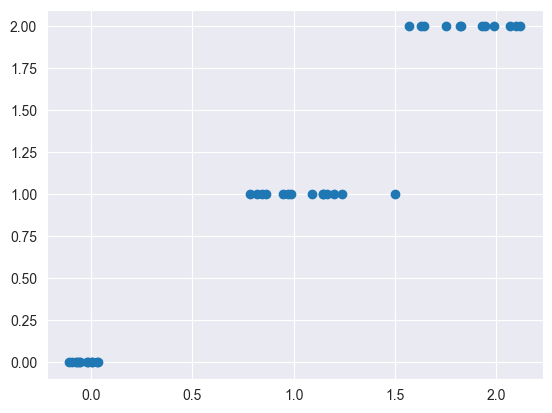

In [242]:
y_pred = grid_svm.predict(X_test_scaled)

mae = mean_absolute_error(y_pred, y_test)
mse = mean_squared_error(y_pred, y_test)
r2 = r2_score(y_pred, y_test)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-Squared:", r2)

plt.scatter(y_pred, y_test)
plt.show()